# 01 - Baseline: Reproducao da Fase 1

Este notebook reproduz o pipeline da Fase 1 usando os modulos refatorados em `src/`.

**Objetivo:** confirmar as metricas de linha de base antes de aplicar o Algoritmo Genetico.

| Modelo | Accuracy | Precision | Recall | F1 |
|--------|----------|-----------|--------|----|
| Regressao Logistica | ~83% | ~13% | **~44%** | ~0.21 |
| Random Forest | ~93% | ~26% | ~24% | ~0.25 |

> **Recall** e a metrica principal (contexto medico: minimizar falsos negativos).

## 0. Setup - instalar dependencias e importar modulos

In [5]:
import sys
from pathlib import Path
import os

if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    sys.path.insert(0, '/content/drive/MyDrive/stroke-prediction')
    print("Rodando no Google Colab")
else:
    sys.path.insert(0, os.path.join(os.getcwd(), '..'))
    print("Rodando Localmente")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import prepare_pipeline
from src.models import (
    train_logistic_regression,
    train_random_forest,
    evaluate_model,
    save_model,
    save_metrics,
)

print('Imports OK')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Rodando no Google Colab
Imports OK


## 1. Carregar e pre-processar os dados

Executa o pipeline completo: `load_data -> clean_data -> encode_features -> split_and_balance (SMOTE)`.

> Se o CSV nao existir, rode primeiro: `python data/download_data.py`

In [6]:
X_train, X_test, y_train, y_test = prepare_pipeline()

print(f'\nFeatures: {list(X_train.columns)}')
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')

Loaded dataset: 5110 rows, 12 columns
Train size (after SMOTE): 7776 (positive: 3888, negative: 3888)
Test size: 1022 (positive: 50)

Features: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'gender_Male', 'ever_married_Yes', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'Residence_type_Urban', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']
X_train shape: (7776, 15)
X_test shape:  (1022, 15)


## 2. Analise de correlacao

Verificacao visual das features mais correlacionadas com `stroke`.

Loaded dataset: 5110 rows, 12 columns


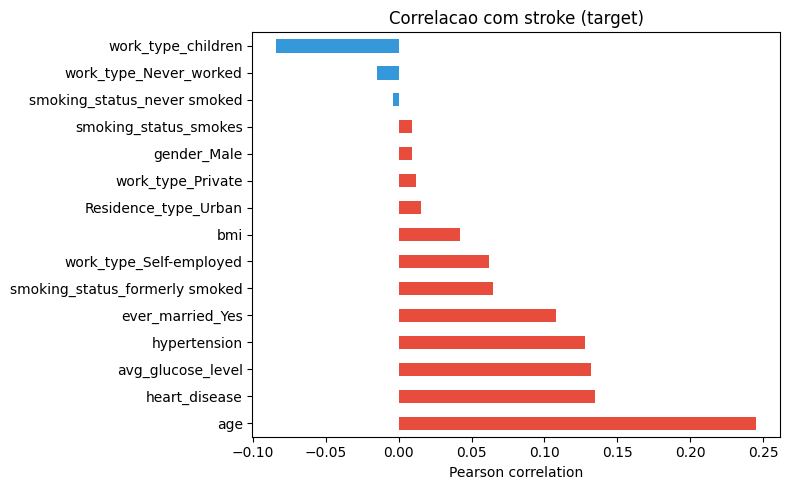

Top 5 features correlacionadas com stroke:
age                  0.245239
heart_disease        0.134905
avg_glucose_level    0.131991
hypertension         0.127891
ever_married_Yes     0.108299
Name: stroke, dtype: float64


In [7]:
import numpy as np

# Reconstruct full df (pre-split) just for correlation
from src.preprocessing import load_data, clean_data, encode_features
df_full = encode_features(clean_data(load_data()))

corr = df_full.corr(numeric_only=True)
stroke_corr = corr['stroke'].drop('stroke').sort_values(ascending=False)

plt.figure(figsize=(8, 5))
stroke_corr.plot(kind='barh', color=['#e74c3c' if v > 0 else '#3498db' for v in stroke_corr])
plt.title('Correlacao com stroke (target)')
plt.xlabel('Pearson correlation')
plt.tight_layout()
plt.show()

print('Top 5 features correlacionadas com stroke:')
print(stroke_corr.head())

## 3. Treinar modelos baseline

In [8]:
print('Treinando Logistic Regression (baseline)...')
lr_model = train_logistic_regression(X_train, y_train)

print('\nTreinando Random Forest (baseline)...')
rf_model = train_random_forest(X_train, y_train)

Treinando Logistic Regression (baseline)...

Treinando Random Forest (baseline)...


## 4. Avaliar modelos e confirmar metricas da Fase 1

In [9]:
lr_metrics = evaluate_model(lr_model, X_test, y_test, 'Logistic Regression (baseline)')
rf_metrics = evaluate_model(rf_model, X_test, y_test, 'Random Forest (baseline)')


  Logistic Regression (baseline)
  Accuracy : 0.8337 (83.37%)
  Precision: 0.1341
  Recall   : 0.4400  <-- primary metric
  F1-Score : 0.2056
  Confusion matrix (TN FP / FN TP): [[830, 142], [28, 22]]

  Random Forest (baseline)
  Accuracy : 0.9286 (92.86%)
  Precision: 0.2553
  Recall   : 0.2400  <-- primary metric
  F1-Score : 0.2474
  Confusion matrix (TN FP / FN TP): [[937, 35], [38, 12]]


## 5. Visualizacao comparativa

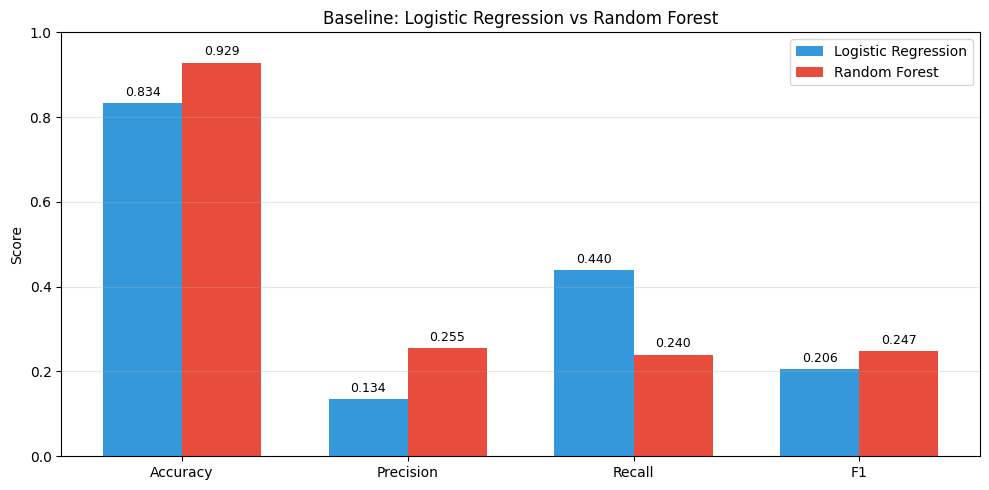

In [10]:
metrics_names = ['accuracy', 'precision', 'recall', 'f1']
lr_vals = [lr_metrics[m] for m in metrics_names]
rf_vals = [rf_metrics[m] for m in metrics_names]

x = range(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar([i - width/2 for i in x], lr_vals, width, label='Logistic Regression', color='#3498db')
bars2 = ax.bar([i + width/2 for i in x], rf_vals, width, label='Random Forest', color='#e74c3c')

ax.set_ylabel('Score')
ax.set_title('Baseline: Logistic Regression vs Random Forest')
ax.set_xticks(list(x))
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1'])
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.01, f'{h:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Salvar modelos e metricas

Os arquivos `.joblib` em `results/` sao usados pelo **Integrante 2** (LLM integration)
e pelo **Integrante 1** nos experimentos do Algoritmo Genetico.

In [11]:
save_model(lr_model, 'logistic_regression')
save_model(rf_model, 'random_forest')

save_metrics([lr_metrics, rf_metrics], 'baseline_metrics.json')

print('\nBaseline concluido. Modelos salvos em results/')

Model saved: /content/drive/MyDrive/stroke-prediction/results/logistic_regression.joblib
Model saved: /content/drive/MyDrive/stroke-prediction/results/random_forest.joblib
Metrics saved: /content/drive/MyDrive/stroke-prediction/results/baseline_metrics.json

Baseline concluido. Modelos salvos em results/


## 7. Conclusao

- **Regressao Logistica** tem o melhor Recall (~44%) - metrica principal para diagnostico de AVC.
- **Random Forest** tem melhor Accuracy e Precision, mas Recall mais baixo (~24%).
- O Algoritmo Genetico (Fase 2) buscara melhorar o Recall mantendo F1 razoavel.

**Proximo passo:** `notebooks/02_genetic_algorithm.ipynb`